# LSTM: Long Short-Term Memory

Librerias necesarias 

In [1]:
# Librerias necesarias 
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking, Bidirectional, Dropout, Masking
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras.callbacks import EarlyStopping

## Funciones 

A continuación, definiremos las funciones que usaremos en el notebook 

Esta primera función `plot_kfold_history_keras` grafica la pérdida y la precisión promedio de los 5 folds con sombra de desviación estándar.

In [ ]:
import matplotlib.pyplot as plt

def plot_kfold_history_keras(fold_histories, title='Métricas K-Fold LSTM'):
    """
    Grafica Loss y Accuracy promedio de los 5 folds con sombra de desviación estándar.
    """
    
    if not fold_histories:
        print("Error: No hay historias para graficar.")
        return

    # Encontramos la longitud mínima (por si hubo Early Stopping en tiempos distintos)
    # Cortamos todas las gráficas a la longitud del entrenamiento más corto
    min_epochs = min(len(h['loss']) for h in fold_histories)
    
    print(f"Graficando las primeras {min_epochs} épocas comunes")

    # Creamos arrays para promedios
    metrics_map = {
        'loss': 'loss', 
        'val_loss': 'val_loss', 
        'acc': 'accuracy',       
        'val_acc': 'val_accuracy' 
    }
    
    data = {k: np.zeros((len(fold_histories), min_epochs)) for k in metrics_map.keys()}

    # Rellenamos datos recortando al mínimo común
    for i, history in enumerate(fold_histories):
        for key_out, key_in in metrics_map.items(): # key_out es 'acc' (para el plot), key_in es 'accuracy' (lo que viene de Keras)
            if key_in in history:
                data[key_out][i, :] = history[key_in][:min_epochs]
            else:
                print(f"Métrica '{key_in}' no encontrada en el historial.")

    # 4. Calculamos medias y desviaciones
    means = {m: np.mean(data[m], axis=0) for m in data}
    stds = {m: np.std(data[m], axis=0) for m in data}
    epochs_range = range(1, min_epochs + 1)

    # PLOT 1: LOSS 
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    # Train Loss
    plt.plot(epochs_range, means['loss'], label='Train Loss', color='blue')
    plt.fill_between(epochs_range, means['loss'] - stds['loss'], means['loss'] + stds['loss'], color='blue', alpha=0.1)
    # Val Loss
    plt.plot(epochs_range, means['val_loss'], label='Val Loss', color='red')
    plt.fill_between(epochs_range, means['val_loss'] - stds['val_loss'], means['val_loss'] + stds['val_loss'], color='red', alpha=0.1)
    
    plt.title(f'{title} - Pérdida')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # PLOT 2: ACCURACY
    plt.subplot(1, 2, 2)
    # Train Acc
    plt.plot(epochs_range, means['acc'], label='Train Acc', color='blue')
    plt.fill_between(epochs_range, means['acc'] - stds['acc'], means['acc'] + stds['acc'], color='blue', alpha=0.1)
    # Val Acc
    plt.plot(epochs_range, means['val_acc'], label='Val Acc', color='green')
    plt.fill_between(epochs_range, means['val_acc'] - stds['val_acc'], means['val_acc'] + stds['val_acc'], color='green', alpha=0.1)
    
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

La función `graficar_matriz_confusion` recibe las predicciones y etiquetas reales y genera la matriz

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def graficar_matriz_confusion(y_true, y_pred, nombre_modelo="Modelo"):
    """
    Recibe las predicciones y etiquetas reales y pinta la matriz.
    """
    print(f"Generando Matriz de Confusión para: {nombre_modelo}")
    
    # Aseguramos enteros
    y_true_int = y_true.astype(int)
    y_pred_int = (y_pred > 0.5).astype(int)

    # Calculamos la matriz de confusión
    cm = confusion_matrix(y_true_int, y_pred_int)

    # Graficamos la matriz de confusión
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Incorrecta', 'Correcta'],
                yticklabels=['Incorrecta', 'Correcta'])
    plt.title(f'Matriz de Confusión: {nombre_modelo}')
    plt.ylabel('Realidad')
    plt.xlabel('Predicción')
    plt.show()

Definimos las siguientes funciones:  
- `train_single_fold`: se encarga de crear, entrenar, evaluar y predecir para UN solo pliegue. 
- `run_kfold_experiment`: se encarga de rrquestar el GroupKFold para evitar Data Leakage con datos aumentados.

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, GroupKFold
from tensorflow.keras.callbacks import EarlyStopping

# 1. GESTOR DE UN SOLO PLIEGUE (FOLD MANAGER)
def train_single_fold(model_fn, X_train_f, y_train_f, X_val_f, y_val_f, 
                      timesteps, features, epochs, batch_size, patience, fold_n):
    """
    Se encarga de crear, entrenar, evaluar y predecir para UN solo pliegue.
    """
    
    # Configuramos Callbacks
    callbacks_list = []
    if patience is not None and patience > 0:
        early_stopping = EarlyStopping(
            monitor='val_loss', 
            patience=patience, 
            restore_best_weights=True,
            verbose=0
        )
        callbacks_list.append(early_stopping)

    # Instanciamos Modelo (Limpio)
    model = model_fn(timesteps, features) 
    
    # Entrenamos
    history = model.fit(
        X_train_f, y_train_f,
        validation_data=(X_val_f, y_val_f),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks_list,
        verbose=0 # Silencioso para no saturar la consola
    )
    
    # Evaluamos Métricas
    loss, acc = model.evaluate(X_val_f, y_val_f, verbose=0)
    
    # Generamos Predicciones (Inferencia)
    y_pred_prob = model.predict(X_val_f, verbose=0)
    
    # Conversión Probabilidad -> Clase
    if y_pred_prob.shape[-1] == 1:
        # Caso Binario Sigmoid
        y_pred_class = (y_pred_prob > 0.5).astype(int).flatten()
    else:
        # Caso Softmax
        y_pred_class = np.argmax(y_pred_prob, axis=-1)
        
    return acc, loss, history.history, y_pred_class


# 2. ORQUESTADOR PRINCIPAL (GROUP K-FOLD)
def run_kfold_experiment(model_fn, X_train, y_train, groups,
                                    epochs, batch_size, n_splits=5, patience=None):
    """
    Orquesta el GroupKFold para evitar Data Leakage con datos aumentados.
    
    Args:
        groups (np.array): Array de IDs que vincula muestras originales con sus aumentaciones.
    """
    
    # Usamos GroupKFold en lugar de KFold estándar
    gkf = GroupKFold(n_splits=n_splits)
    
    # Acumuladores
    fold_accuracies = []
    fold_histories = []
    
    # Listas para reordenamiento
    global_y_true_unsorted = []
    global_y_pred_unsorted = []
    global_indices = [] 
    
    print(f"GroupKFold Keras ({n_splits} splits)")
    print(f"(Grupos detectados: {len(np.unique(groups))})")
    print("===" * 20)
    
    _, timesteps, features = X_train.shape

    # Pasamos 'groups' al split
    for fold_idx, (train_index, val_index) in enumerate(gkf.split(X_train, y_train, groups=groups)):
        print(f"\nPliegue {fold_idx + 1}/{n_splits}")

        # Preparamos los datos
        X_train_f, X_val_f = X_train[train_index], X_train[val_index]
        y_train_f, y_val_f = y_train[train_index], y_train[val_index]

        # Delegamos trabajo a train_single_fold
        acc, loss, history, fold_preds = train_single_fold(
            model_fn, X_train_f, y_train_f, X_val_f, y_val_f,
            timesteps, features, epochs, batch_size, patience, fold_idx+1
        )
        
        print(f"Fin Fold {fold_idx+1}. Acc Val: {acc:.4f} | Loss: {loss:.4f}")
        
        # Recolectamos resultados
        fold_accuracies.append(acc)
        fold_histories.append(history)
        
        global_y_true_unsorted.extend(y_val_f)
        global_y_pred_unsorted.extend(fold_preds)
        global_indices.extend(val_index)

    # Reordenamiento final
    global_indices_np = np.array(global_indices)
    sorted_order = np.argsort(global_indices_np)
    
    final_y_true = np.array(global_y_true_unsorted)[sorted_order]
    final_y_pred = np.array(global_y_pred_unsorted)[sorted_order]
    
    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)

    print("===" * 20)
    print(f"Resultados GroupKFold:")
    print(f"Accuracy Medio: {mean_acc:.4f}")
    print(f"Desviación Std: {std_acc:.4f}")
    
    return mean_acc, std_acc, fold_histories, final_y_true, final_y_pred

La función `calcular_bootstrap_intervalo` calcula el intervalo de confianza usando Bootstrapping sobre las predicciones.

In [ ]:
from sklearn.utils import resample
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

def calcular_bootstrap_intervalo(y_true, y_pred, n_iterations=1000, alpha=0.95):
    """
    Calcula el intervalo de confianza usando Bootstrapping sobre las predicciones.
    """
    stats = []
    
    # Bucle de simulaciones (1000 veces)
    for i in range(n_iterations):
        # Generamos índices aleatorios con reemplazo
        # (Simula meter la mano en la bolsa y sacar bolas repetidas)
        indices = resample(range(len(y_pred)), replace=True)
        
        # Creamos el "dataset virtual"
        sample_pred = y_pred[indices]
        sample_true = y_true[indices]
        
        # Calculamos el accuracy de esta simulación
        score = accuracy_score(sample_true, sample_pred)
        stats.append(score)
    
    # 2. Ordenamos los 1000 resultados de menor a mayor
    stats = np.sort(stats)
    
    # 3. Calculamos los límites (cortamos las colas)
    lower_percentile = ((1.0 - alpha) / 2.0) * 100
    upper_percentile = (alpha + ((1.0 - alpha) / 2.0)) * 100
    
    lower = np.percentile(stats, lower_percentile)
    upper = np.percentile(stats, upper_percentile)
    
    print(f"Accuracy Promedio (Bootstrap): {np.mean(stats):.4f}")
    print(f"Intervalo de Confianza {int(alpha*100)}%: [{lower:.4f}, {upper:.4f}]")
    
    return lower, upper, stats

Con `create_custom_lstm` creamos lstm con personalizadas, indicando los parámetros que desamos que tengan.

In [ ]:
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

def create_custom_lstm(timesteps, features, 
                       lstm_layers=[64], # lstm_layers: [128, 64] crea dos capas LSTM apiladas
                       dense_layers=[32], # dense_layers: [64, 32] crea dos capas densas
                       dropout_rate=0.2, 
                       learning_rate=0.001,
                       bidirectional=False,
                       optimizer_name='adam'): # Puede ser 'adam', 'sgd', 'rmsprop'
    
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    
    # Bucle para CAPAS LSTM (Automático: detecta si debe devolver secuencias). Crea tantas capas LSTM como se indiquen en lstm_layers, además de aplicar Dropout si es necesario
    for i, units in enumerate(lstm_layers):
            is_last_lstm = (i == len(lstm_layers) - 1)
            
            # Definimos la capa base
            lstm_layer = LSTM(units, return_sequences=not is_last_lstm)
            
            # Decidimos si la envolvemos en Bidirectional o no
            if bidirectional:
                model.add(Bidirectional(lstm_layer))
            else:
                model.add(lstm_layer)
                
            if dropout_rate > 0:
                model.add(Dropout(dropout_rate))
    
    # Bucle para CAPAS DENSAS. 
    for units in dense_layers:
        model.add(Dense(units, activation='relu'))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    # Capa de Salida
    model.add(Dense(1, activation='sigmoid'))
    
    # Selector de Optimizador
    if optimizer_name.lower() == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_name.lower() == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer_name.lower() == 'sgd':
        opt = SGD(learning_rate=learning_rate)
    else:
        opt = Adam(learning_rate=learning_rate)
    
    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model



Por último, `ejecutar_experimento_individual` entrena con GroupKFold, calcula Bootstrap, grafica el resultado y guarda los datos.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Inicializamos la lista que contendrá los resultados (Globales)
results_table = [] 

# Definimos la función que hace todo (Entrenar + Bootstrap + Graficar)
def ejecutar_experimento_individual(name, lstm_layers, dense_layers, dropout, lr, opt_name, patience, bidirectional=False, epochs=40, batch_size=16):
    """
    1. Entrena con GroupKFold.
    2. Calcula Bootstrap.
    3. GRAFICA el resultado inmediatamente.
    4. Guarda los datos en la tabla global.
    """
    print(f"Iniciando: {name}")
    print(f"Arq: LSTM={lstm_layers} (Bi={bidirectional}) | Dense={dense_layers}")
    print(f"Params: Opt={opt_name} | LR={lr} | Drop={dropout} | Patience={patience}")
    print("-" * 60)
    
    # Construimos el modelo con los parámetros pasados
    model_builder = lambda t, f: create_custom_lstm(
        t, f, 
        lstm_layers=lstm_layers,
        dense_layers=dense_layers,
        dropout_rate=dropout, 
        learning_rate=lr,
        optimizer_name=opt_name
    )
    
    # Ejecutamos el K-Fold pasando el 'patience' para el Early Stopping
    mean_acc, std_acc, histories, final_y_true, final_y_pred = run_kfold_experiment(
        model_fn=model_builder,
        X_train=X_total, y_train=y_total, groups=groups,
        epochs=epochs, batch_size=batch_size, n_splits=5, 
        patience=patience 
    )

    # Calculamos Bootstrap 
    print(f"Calculando Bootstrap (10,000 iteraciones)")
    n_iterations = 10000
    lower, upper, stats = calcular_bootstrap_intervalo(
        final_y_true, final_y_pred, n_iterations=n_iterations, alpha=0.95
    )
    
    boot_mean = np.mean(stats) # Calculamos la media de las simulaciones
    
    print(f"Resultado: Acc Promedio {boot_mean:.4f} | IC 95%: [{lower:.4f}, {upper:.4f}]")

    # Gráficas de entrenamiento 
    print("\nCurvas de aprendizaje promedio:")
    plot_kfold_history_keras(histories, title=f'Modelo: {name}')

    # Gráficas de Bootstrap
    plt.figure(figsize=(10, 6))

    # 1. Histograma normalizado
    plt.hist(stats, bins=30, color='skyblue', edgecolor='black', 
             density=True, alpha=0.6, label='Frecuencia (Normalizada)')

    # 2. Gráfico KDE
    sns.kdeplot(stats, color='orange', lw=3, label='KDE (Estimación No Paramétrica)')

    # Líneas verticales para el intervalo de confianza (Opcional, pero recomendado visualmente)
    plt.axvline(lower, color='red', linestyle='--', alpha=0.8, label=f'Límite Inf ({lower:.3f})')
    plt.axvline(upper, color='green', linestyle='--', alpha=0.8, label=f'Límite Sup ({upper:.3f})')

    plt.title(f'Distribución de Accuracies - Modelo: {name}\n(Bootstrap k={n_iterations})')
    plt.xlabel('Accuracy')
    plt.ylabel('Densidad de Probabilidad')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show() 

    # Guardamos en tabla global
    # Borramos si ya existía este modelo para actualizarlo
    global results_table
    results_table = [r for r in results_table if r['Modelo'] != name]
    results_table.append({
        'Modelo': name,
        'Acc CV': mean_acc,
        'Acc Boot': boot_mean,
        'IC 95%': f"[{lower:.3f}-{upper:.3f}]",
        'LSTM Layers': str(lstm_layers), # Lo guardamos como texto para leerlo más fácil
        'Bidirectional': bidirectional,
        'Dense Layers': str(dense_layers),
        'Optimizador': opt_name,
        'Batch_size' : batch_size,
        'Epochs' : epochs,
        'LR': lr,
        'Dropout': dropout,
        'Patience': patience
    })

    # 3. Guardamos los resultados de Bootstrap en un archivo .npy para análisis posterior
    filename = f"../results/bootstrap_accuracies_exp_{name}.npy"
    np.save(filename, stats)

    return final_y_true, final_y_pred # Devuelve los valores reales y predichos para la matriz de confusión


## Experimentación con aumentacion con Landmarks

Usaremos los ficheros de datos con puntos clave (originales y espejados)

In [ ]:
import numpy as np

# Cargamos los datos 
X_correct_mirrored = np.load('../Data/Processed/mirrored_correct_push_ups_landmarks.npy')
X_incorrect_mirrored = np.load('../Data/Processed/mirrored_wrong_push_ups_landmarks.npy')
X_correct_original = np.load('../Data/Processed/correct_push_ups_landmarks.npy')
X_incorrect_original = np.load('../Data/Processed/wrong_push_ups_landmarks.npy')

# Concatenamos clases para formar X e y (Mirrored y Original por separado primero)
# MIRRORED
X_mirrored = np.vstack((X_correct_mirrored, X_incorrect_mirrored))
y_mirrored = np.array([1]*len(X_correct_mirrored) + [0]*len(X_incorrect_mirrored))

# ORIGINAL
X_original = np.vstack((X_correct_original, X_incorrect_original))
y_original = np.array([1]*len(X_correct_original) + [0]*len(X_incorrect_original))

# Creamos los grupos 
# El video i-ésimo de X_original corresponde al video i-ésimo de X_mirrored
# Creamos un ID único para cada video original
original_ids = np.arange(len(X_original))
mirrored_ids = np.arange(len(X_mirrored)) # Igual que el anterior

# Juntamos todo (Original + Mirrored)
X_total = np.concatenate((X_original, X_mirrored), axis=0)
y_total = np.concatenate((y_original, y_mirrored), axis=0)

# El array 'groups' le dice al KFold qué filas son "hermanas"
groups = np.concatenate((original_ids, mirrored_ids), axis=0) # Evita fugas de datos, usa el video original y espejado en el mismo conjunto 

print(f"Forma de X_total: {X_total.shape}")
print(f"Forma de y_total: {y_total.shape}")
print(f"Forma de groups: {groups.shape}")
print(f"Ejemplo: El dato en índice 0 (orig) y el índice {len(X_original)} (mirror) tienen el grupo {groups[0]} y {groups[len(X_original)]}")

Forma de X_total: (200, 160, 66)
Forma de y_total: (200,)
Forma de groups: (200,)
Ejemplo: El dato en índice 0 (orig) y el índice 100 (mirror) tienen el grupo 0 y 0


In [9]:
groups

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99,  0,  1,
        2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52,
       53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69,
       70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86,
       87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [10]:
# Definimos parámetros
TIMESTEPS = X_total.shape[1]
FEATURES = X_total.shape[2]

### Exp-LSTM-03

Iniciando: LSTM_03
Arq: LSTM=[128, 64] (Bi=False) | Dense=[64, 32]
Params: Opt=adam | LR=5e-05 | Drop=0.2 | Patience=15
------------------------------------------------------------
GroupKFold Keras (5 splits)
(Grupos detectados: 100)

Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fin Fold 1. Acc Val: 0.8500 | Loss: 0.4269

Pliegue 2/5
Fin Fold 2. Acc Val: 0.9000 | Loss: 0.2715

Pliegue 3/5
Fin Fold 3. Acc Val: 0.9250 | Loss: 0.2415

Pliegue 4/5
Fin Fold 4. Acc Val: 0.8500 | Loss: 0.4065

Pliegue 5/5
Fin Fold 5. Acc Val: 0.9250 | Loss: 0.2132
Resultados GroupKFold:
Accuracy Medio: 0.8900
Desviación Std: 0.0339
Calculando Bootstrap (10,000 iteraciones)
Accuracy Promedio (Bootstrap): 0.8901
Intervalo de Confianza 95%: [0.8450, 0.9300]
Resultado: Acc Promedio 0.8901 | IC 95%: [0.8450, 0.9300]

Curvas de aprendizaje promedio:
Graficando las primeras 64 épocas comunes


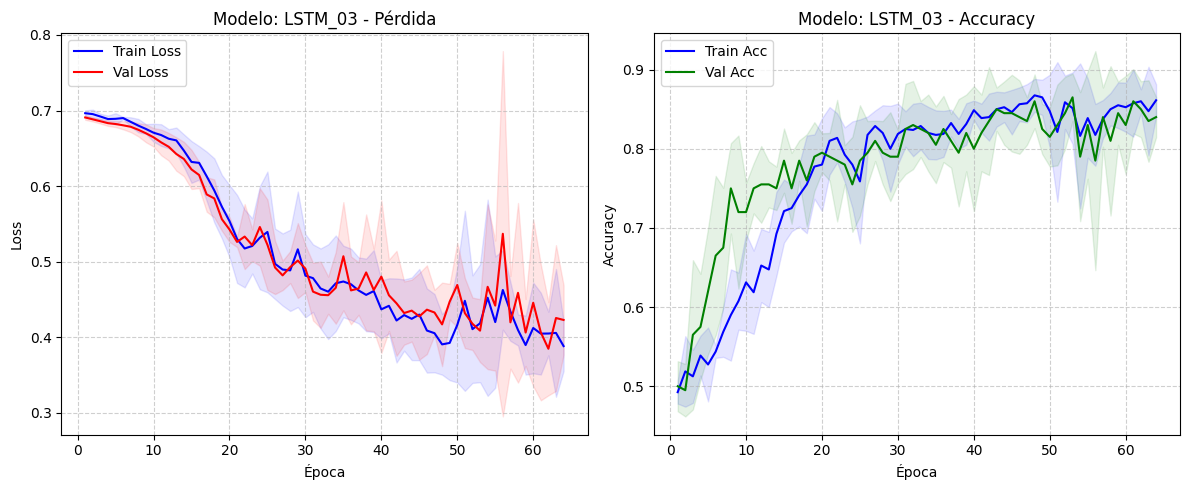

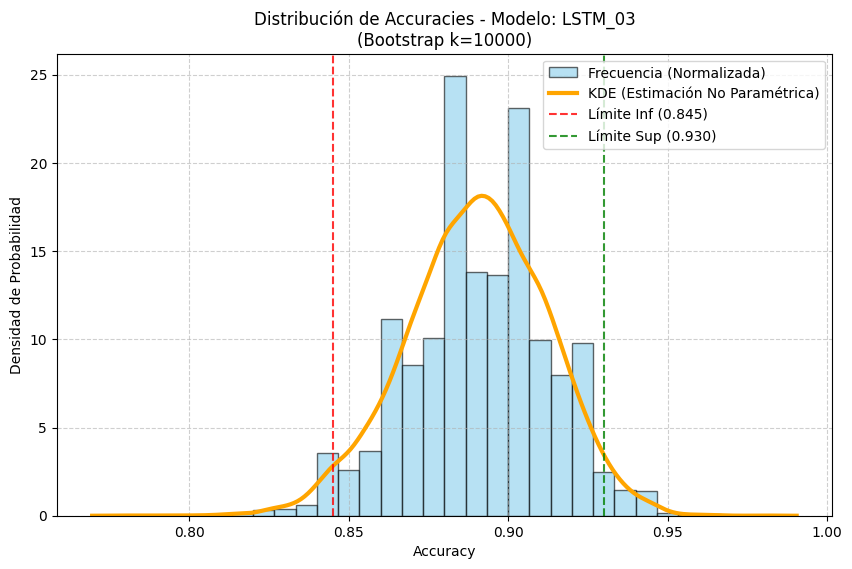

In [ ]:
y_real, y_predicha = ejecutar_experimento_individual( # LSTM_LongTrain
    name='LSTM_03', 
    lstm_layers=[128, 64],
    dense_layers=[64, 32],
    dropout=0.2,
    lr=0.00005, 
    opt_name='adam',
    patience=15,     
    epochs=100 
)

Generando Matriz de Confusión para: LSTM_03


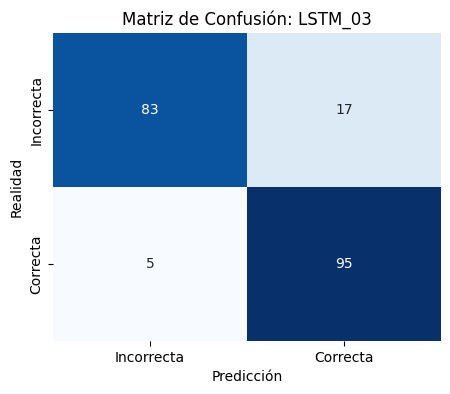

In [13]:
graficar_matriz_confusion(y_real, y_predicha, nombre_modelo="LSTM_03")

### Exp-Bi-LSTM-03

Iniciando: Bi-LSTM_03
Arq: LSTM=[128, 64] (Bi=True) | Dense=[64, 32]
Params: Opt=adam | LR=5e-05 | Drop=0.25 | Patience=10
------------------------------------------------------------
GroupKFold Keras (5 splits)
(Grupos detectados: 100)

Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fin Fold 1. Acc Val: 0.8500 | Loss: 0.4189

Pliegue 2/5
Fin Fold 2. Acc Val: 0.9000 | Loss: 0.2592

Pliegue 3/5
Fin Fold 3. Acc Val: 0.8750 | Loss: 0.5148

Pliegue 4/5
Fin Fold 4. Acc Val: 0.8000 | Loss: 0.4843

Pliegue 5/5
Fin Fold 5. Acc Val: 0.9500 | Loss: 0.2264
Resultados GroupKFold:
Accuracy Medio: 0.8750
Desviación Std: 0.0500
Calculando Bootstrap (10,000 iteraciones)
Accuracy Promedio (Bootstrap): 0.8746
Intervalo de Confianza 95%: [0.8250, 0.9200]
Resultado: Acc Promedio 0.8746 | IC 95%: [0.8250, 0.9200]

Curvas de aprendizaje promedio:
Graficando las primeras 29 épocas comunes


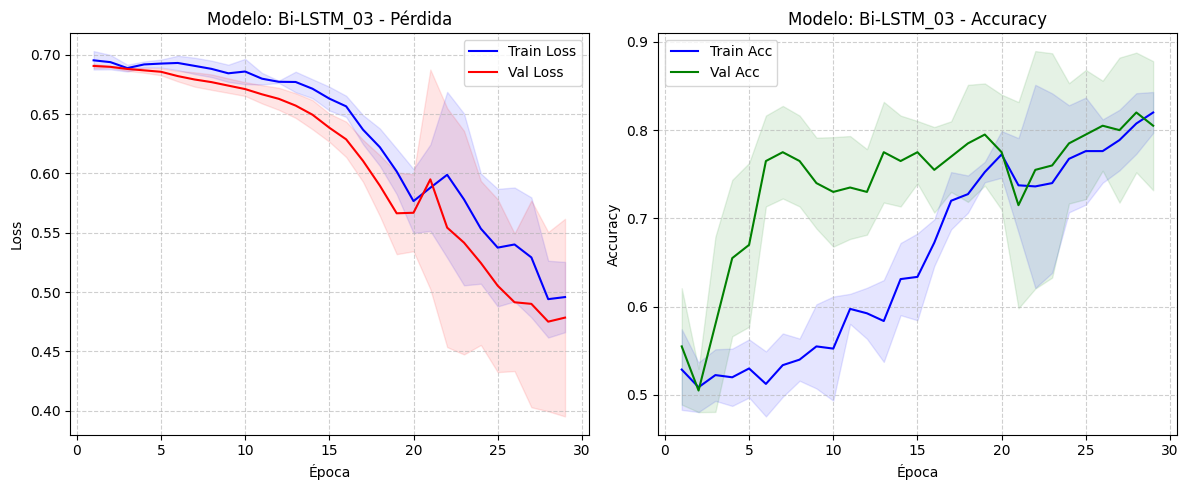

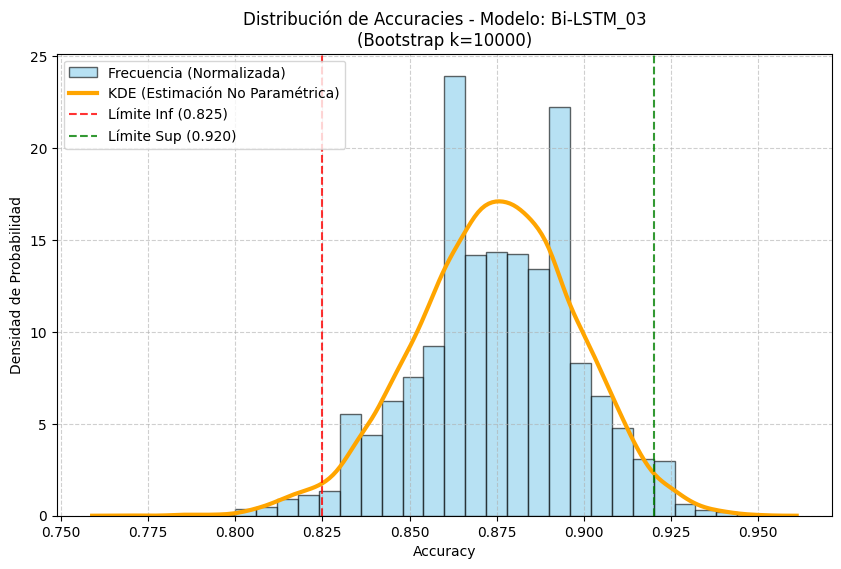

In [ ]:
_, _ = ejecutar_experimento_individual(
    name='Bi-LSTM_03', 
    lstm_layers=[128, 64],
    dense_layers=[64, 32],
    dropout=0.25,
    lr=0.00005,
    opt_name='adam',
    bidirectional=True, # LSTM bidireccional
    patience=10,
    epochs=80
)

## Experimentación con aumentación y datos angulares 

In [ ]:
import numpy as np

# Cargamos los datos 
X_correct_mirrored = np.load('../Data/Processed/mirrored_correct_push_ups_angles.npy')
X_incorrect_mirrored = np.load('../Data/Processed/mirrored_wrong_push_ups_angles.npy')
X_correct_original = np.load('../Data/Processed/correct_push_ups_angles.npy')
X_incorrect_original = np.load('../Data/Processed/wrong_push_ups_angles.npy')

# MIRRORED
X_mirrored = np.vstack((X_correct_mirrored, X_incorrect_mirrored))
y_mirrored = np.array([1]*len(X_correct_mirrored) + [0]*len(X_incorrect_mirrored))

# ORIGINAL
X_original = np.vstack((X_correct_original, X_incorrect_original))
y_original = np.array([1]*len(X_correct_original) + [0]*len(X_incorrect_original))

# Creación de los grupos
original_ids = np.arange(len(X_original))
mirrored_ids = np.arange(len(X_mirrored)) # Debería ser igual al anterior si están ordenados

# Juntamos todo (Original + Mirrored)
X_total = np.concatenate((X_original, X_mirrored), axis=0)
y_total = np.concatenate((y_original, y_mirrored), axis=0)

groups = np.concatenate((original_ids, mirrored_ids), axis=0)

print(f"Forma de X_total: {X_total.shape}")
print(f"Forma de y_total: {y_total.shape}")
print(f"Forma de groups: {groups.shape}")
print(f"Ejemplo: El dato en índice 0 (orig) y el índice {len(X_original)} (mirror) tienen el grupo {groups[0]} y {groups[len(X_original)]}")

Forma de X_total: (200, 160, 10)
Forma de y_total: (200,)
Forma de groups: (200,)
Ejemplo: El dato en índice 0 (orig) y el índice 100 (mirror) tienen el grupo 0 y 0


### Exp-LSTM-04

Iniciando: LSTM_04
Arq: LSTM=[256, 128] (Bi=False) | Dense=[64, 32]
Params: Opt=adam | LR=5e-05 | Drop=0.3 | Patience=15
------------------------------------------------------------
GroupKFold Keras (5 splits)
(Grupos detectados: 100)

Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fin Fold 1. Acc Val: 0.9750 | Loss: 0.0799

Pliegue 2/5
Fin Fold 2. Acc Val: 0.9750 | Loss: 0.1313

Pliegue 3/5
Fin Fold 3. Acc Val: 1.0000 | Loss: 0.0172

Pliegue 4/5
Fin Fold 4. Acc Val: 0.9500 | Loss: 0.2175

Pliegue 5/5
Fin Fold 5. Acc Val: 1.0000 | Loss: 0.0340
Resultados GroupKFold:
Accuracy Medio: 0.9800
Desviación Std: 0.0187
Calculando Bootstrap (10,000 iteraciones)
Accuracy Promedio (Bootstrap): 0.9800
Intervalo de Confianza 95%: [0.9600, 0.9950]
Resultado: Acc Promedio 0.9800 | IC 95%: [0.9600, 0.9950]

Curvas de aprendizaje promedio:
Graficando las primeras 52 épocas comunes


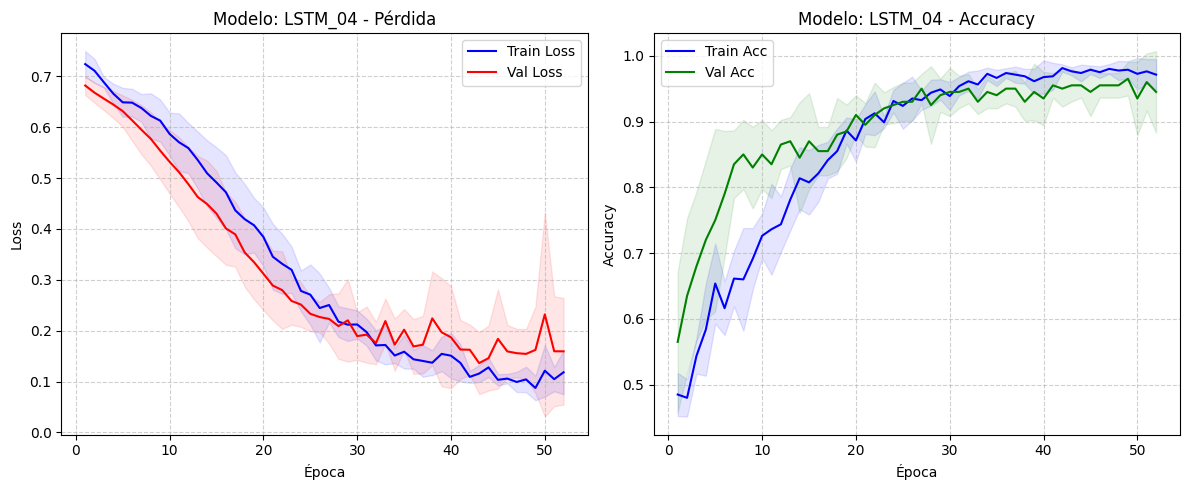

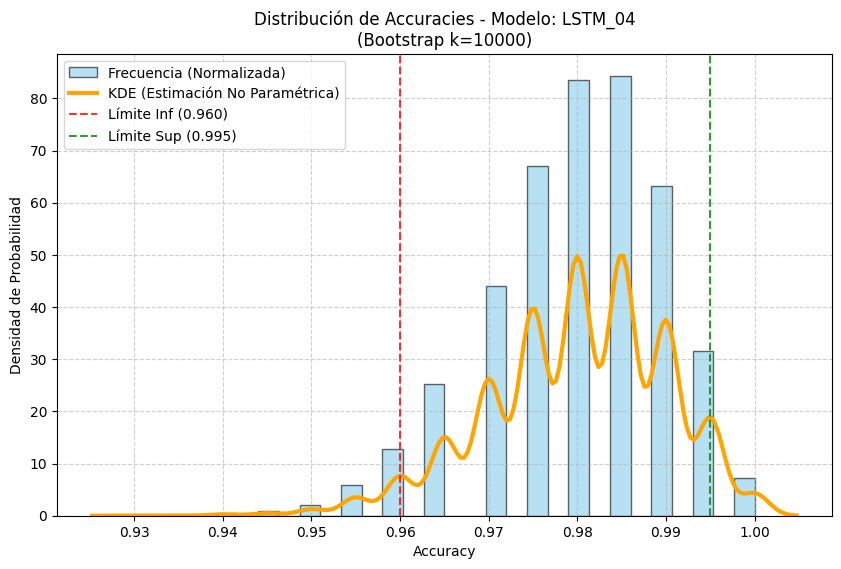

In [ ]:
y_real, y_predicha = ejecutar_experimento_individual( #LSTM_Wide_Angles
    name='LSTM_04', 
    lstm_layers=[256, 128],
    dense_layers=[64, 32],
    dropout=0.3,
    lr=0.00005,
    opt_name='adam',
    patience=15,
    epochs=80
)

Generando Matriz de Confusión para: LSTM_04


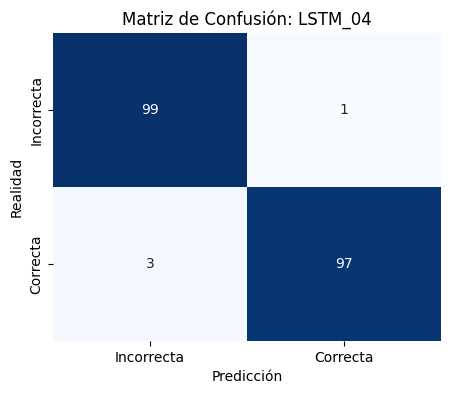

In [17]:
graficar_matriz_confusion(y_real, y_predicha, nombre_modelo="LSTM_04")

### Exp-Bi-LSTM-04

Iniciando: Bi-LSTM_04
Arq: LSTM=[128, 64] (Bi=True) | Dense=[64, 32]
Params: Opt=adam | LR=5e-05 | Drop=0.3 | Patience=20
------------------------------------------------------------
GroupKFold Keras (5 splits)
(Grupos detectados: 100)

Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fin Fold 1. Acc Val: 0.9500 | Loss: 0.1942

Pliegue 2/5
Fin Fold 2. Acc Val: 0.9500 | Loss: 0.0742

Pliegue 3/5
Fin Fold 3. Acc Val: 1.0000 | Loss: 0.0250

Pliegue 4/5
Fin Fold 4. Acc Val: 0.9500 | Loss: 0.1735

Pliegue 5/5
Fin Fold 5. Acc Val: 1.0000 | Loss: 0.0409
Resultados GroupKFold:
Accuracy Medio: 0.9700
Desviación Std: 0.0245
Calculando Bootstrap (10,000 iteraciones)
Accuracy Promedio (Bootstrap): 0.9701
Intervalo de Confianza 95%: [0.9450, 0.9900]
Resultado: Acc Promedio 0.9701 | IC 95%: [0.9450, 0.9900]

Curvas de aprendizaje promedio:
Graficando las primeras 72 épocas comunes


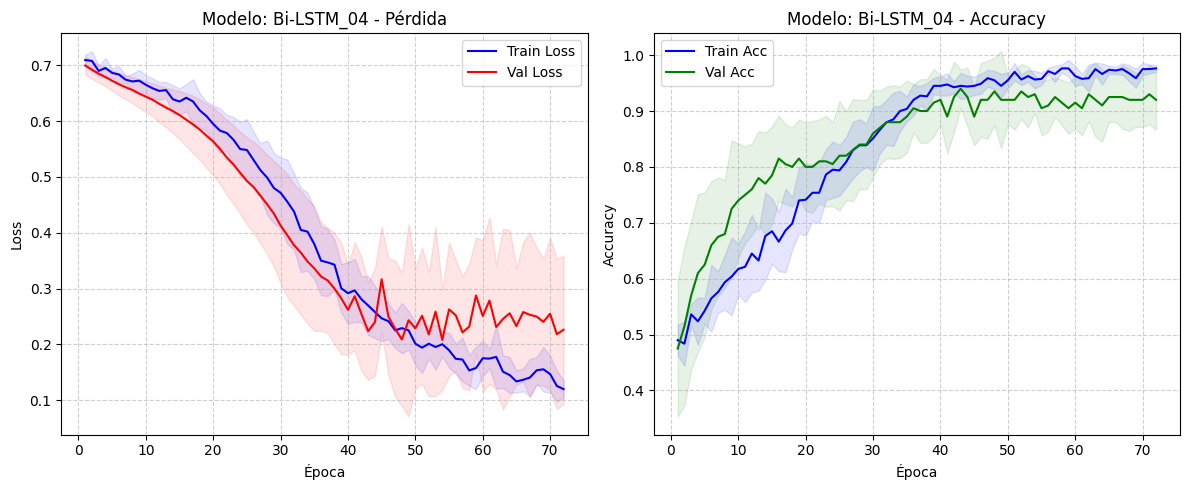

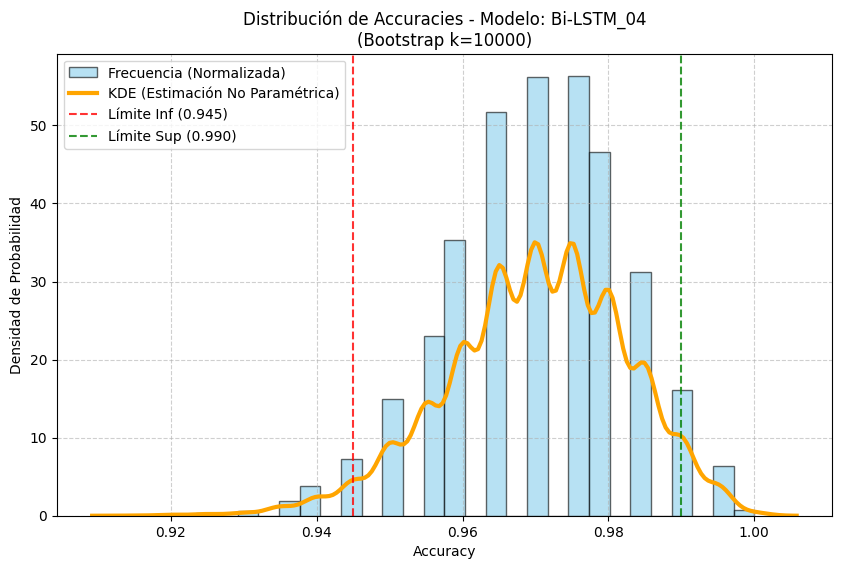

In [19]:
_, _ = ejecutar_experimento_individual(
    name='Bi-LSTM_04', 
    lstm_layers=[128, 64],
    dense_layers=[64, 32],
    dropout=0.3,
    lr=0.00005,
    opt_name='adam',
    bidirectional=True,
    patience=20,
    epochs=120
)

## Experimentación sin aumentación con Landmarks

Para esta experimentación, adaptaremos nuestra función de ejecutar expermientos para no modificarla 

In [ ]:
import numpy as np

# Cargamos los datos
X_correct_original = np.load('../Data/Processed/correct_push_ups_landmarks.npy')
X_incorrect_original = np.load('../Data/Processed/wrong_push_ups_landmarks.npy')

# Preparamos datos de prueba sin espejos
X_test_original = np.vstack((X_correct_original, X_incorrect_original))
y_test_original = np.array([1]*len(X_correct_original) + [0]*len(X_incorrect_original))

# Grupos simples (Cada video es un grupo porque no hay espejos)
groups_original = np.arange(len(X_test_original))

print("Datos para prueba sin espejos preparados:")
print(f"X: {X_test_original.shape}")
print(f"y: {y_test_original.shape}")

🧪 Datos para prueba SIN ESPEJOS preparados:
   X: (100, 160, 66)
   y: (100,)


In [ ]:
def ejecutar_experimento_sin_aumentación(name, lstm_layers, dense_layers, dropout, lr, 
                                         opt_name, patience, bidirectional=False, 
                                         epochs=40, batch_size=16):
    
    print(f"Test de solo originales (sin data augmentation)")
    print(f"Iniciando: {name}")
    print("-" * 60)
    
    # Builder (Igual)
    model_builder = lambda t, f: create_custom_lstm(
        t, f, 
        lstm_layers=lstm_layers,
        dense_layers=dense_layers,
        dropout_rate=dropout, 
        learning_rate=lr,
        optimizer_name=opt_name,
        bidirectional=bidirectional
    )
    
    # Aqui está el unico cambio importante
    # En vez de usar X_total, forzamos el uso de X_test_original
    mean_acc, std_acc, histories, final_y_true, final_y_pred = run_kfold_experiment(
        model_fn=model_builder,
        X_train=X_test_original, # Datos limpios
        y_train=y_test_original, # Etiquetas limpias
        groups=groups_original, # Grupos simples
        epochs=epochs, batch_size=batch_size, n_splits=5, patience=patience 
    )

    # Gráficas
    print("\nCurvas de aprendizaje (Solo Originales)")
    plot_kfold_history_keras(histories, title=f'{name} (Originales)')

    # Bootstrap
    print(f"Calculando Bootstrap")
    lower, upper, stats = calcular_bootstrap_intervalo(final_y_true, final_y_pred, n_iterations=10000)
    boot_mean = np.mean(stats)
    
    # Guardamos en la tabla GLOBAL 
    global results_table
    # Añadimos etiqueta al nombre para diferenciarlo en la tabla
    name_tagged = name + "_SOLO_ORIGINAL"
    
    results_table.append({
        'Modelo': name_tagged,    
        'Dataset': 'SOLO_ORIGINAL', 
        'Acc CV': mean_acc,
        'Acc Boot': boot_mean,
        'IC 95%': f"[{lower:.3f}-{upper:.3f}]",
        'LSTM Layers': str(lstm_layers), 
        'Bidirectional': bidirectional,
        'Dense Layers': str(dense_layers), 
        'Optimizador': opt_name,           
        'Batch_size' : batch_size,         
        'Epochs': epochs,
        'LR': lr,                          
        'Dropout': dropout,                
        'Patience': patience
    })
    
    print(f"Guardado como '{name_tagged}'. Acc: {boot_mean:.4f}")

    # 3. Guardamos
    filename = f"../results/bootstrap_accuracies_exp_{name}.npy"
    np.save(filename, stats)

    return final_y_true, final_y_pred

### Exp-LSTM-01

Test de solo originales (sin data augmentation)
Iniciando: LSTM_01
------------------------------------------------------------
GroupKFold Keras (5 splits)
(Grupos detectados: 100)

Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fin Fold 1. Acc Val: 0.9000 | Loss: 0.3718

Pliegue 2/5
Fin Fold 2. Acc Val: 0.7000 | Loss: 0.5738

Pliegue 3/5
Fin Fold 3. Acc Val: 0.8000 | Loss: 0.4749

Pliegue 4/5
Fin Fold 4. Acc Val: 0.8500 | Loss: 0.4875

Pliegue 5/5
Fin Fold 5. Acc Val: 0.8000 | Loss: 0.4229
Resultados GroupKFold:
Accuracy Medio: 0.8100
Desviación Std: 0.0663

Curvas de aprendizaje (Solo Originales)
Graficando las primeras 25 épocas comunes


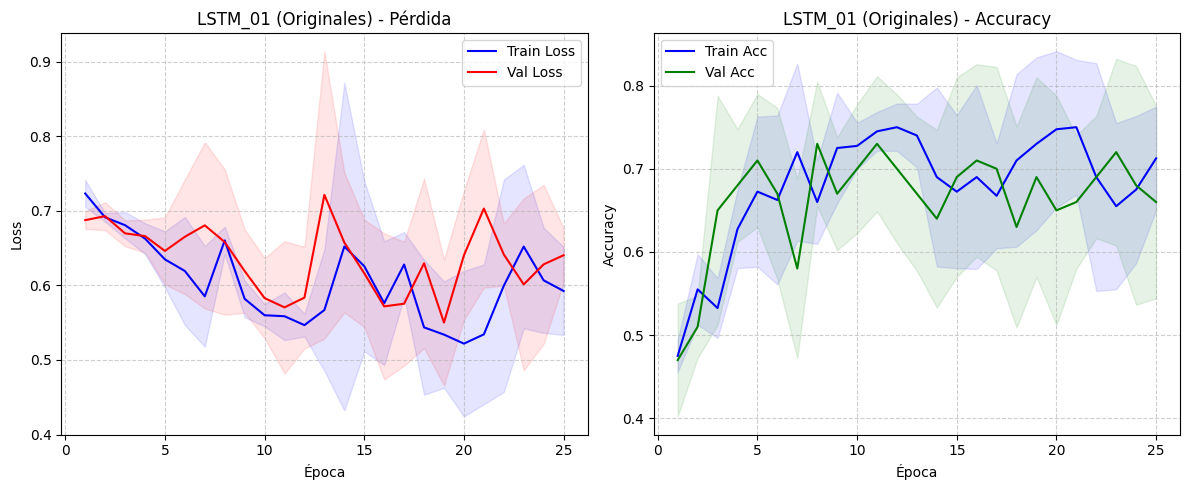

Calculando Bootstrap
Accuracy Promedio (Bootstrap): 0.8095
Intervalo de Confianza 95%: [0.7300, 0.8800]
Guardado como 'LSTM_01_SOLO_ORIGINAL'. Acc: 0.8095


In [ ]:
_, _ = ejecutar_experimento_sin_aumentación(
    name='LSTM_01', 
    lstm_layers=[64],  
    dense_layers=[32], 
    bidirectional=False,
    dropout=0.2, 
    lr=0.001, 
    opt_name='adam', 
    patience=15
)

### Exp-LSTM-01-deep

Test de solo originales (sin data augmentation)
Iniciando: LSTM_01-deep
------------------------------------------------------------
GroupKFold Keras (5 splits)
(Grupos detectados: 100)

Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fin Fold 1. Acc Val: 0.7500 | Loss: 0.5793

Pliegue 2/5
Fin Fold 2. Acc Val: 0.7500 | Loss: 0.5179

Pliegue 3/5
Fin Fold 3. Acc Val: 0.7000 | Loss: 0.6270

Pliegue 4/5
Fin Fold 4. Acc Val: 0.9000 | Loss: 0.3342

Pliegue 5/5
Fin Fold 5. Acc Val: 0.8000 | Loss: 0.5358
Resultados GroupKFold:
Accuracy Medio: 0.7800
Desviación Std: 0.0678

Curvas de aprendizaje (Solo Originales)
Graficando las primeras 20 épocas comunes


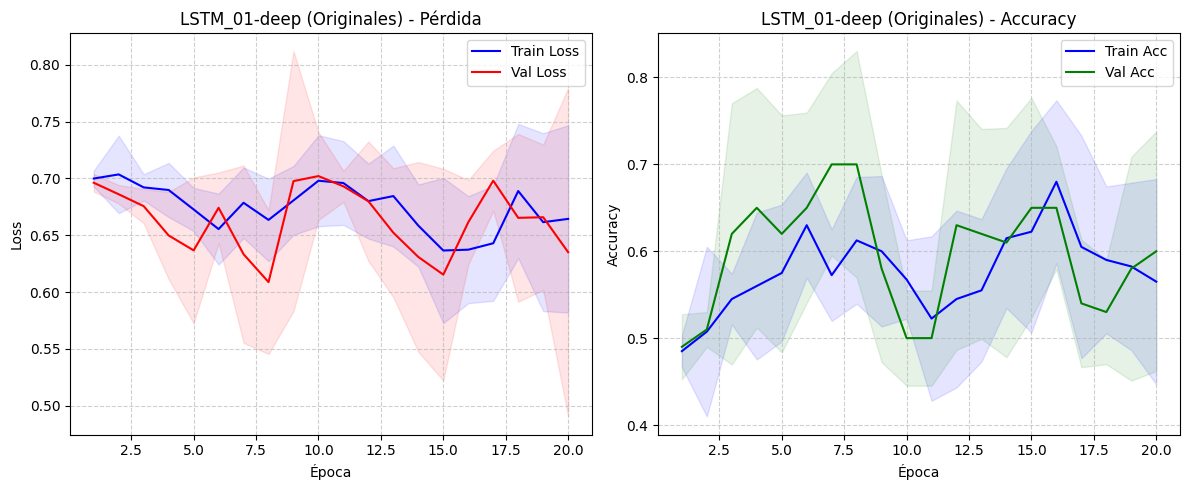

Calculando Bootstrap
Accuracy Promedio (Bootstrap): 0.7808
Intervalo de Confianza 95%: [0.7000, 0.8600]
Guardado como 'LSTM_01-deep_SOLO_ORIGINAL'. Acc: 0.7808


In [ ]:
_, _ = ejecutar_experimento_sin_aumentación(
    name='LSTM_01-deep', 
    lstm_layers=[128, 64],  
    dense_layers=[64, 32], 
    bidirectional=False,
    dropout=0.2, 
    lr=0.001, 
    opt_name='adam', 
    patience=15,
    epochs = 100
)

### Exp-Bi-LSTM-01

Test de solo originales (sin data augmentation)
Iniciando: Bi-LSTM_01
------------------------------------------------------------
GroupKFold Keras (5 splits)
(Grupos detectados: 100)

Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fin Fold 1. Acc Val: 0.7500 | Loss: 0.5414

Pliegue 2/5
Fin Fold 2. Acc Val: 0.8000 | Loss: 0.3848

Pliegue 3/5
Fin Fold 3. Acc Val: 0.6000 | Loss: 0.6686

Pliegue 4/5
Fin Fold 4. Acc Val: 0.9000 | Loss: 0.3067

Pliegue 5/5
Fin Fold 5. Acc Val: 0.8000 | Loss: 0.4435
Resultados GroupKFold:
Accuracy Medio: 0.7700
Desviación Std: 0.0980

Curvas de aprendizaje (Solo Originales)
Graficando las primeras 42 épocas comunes


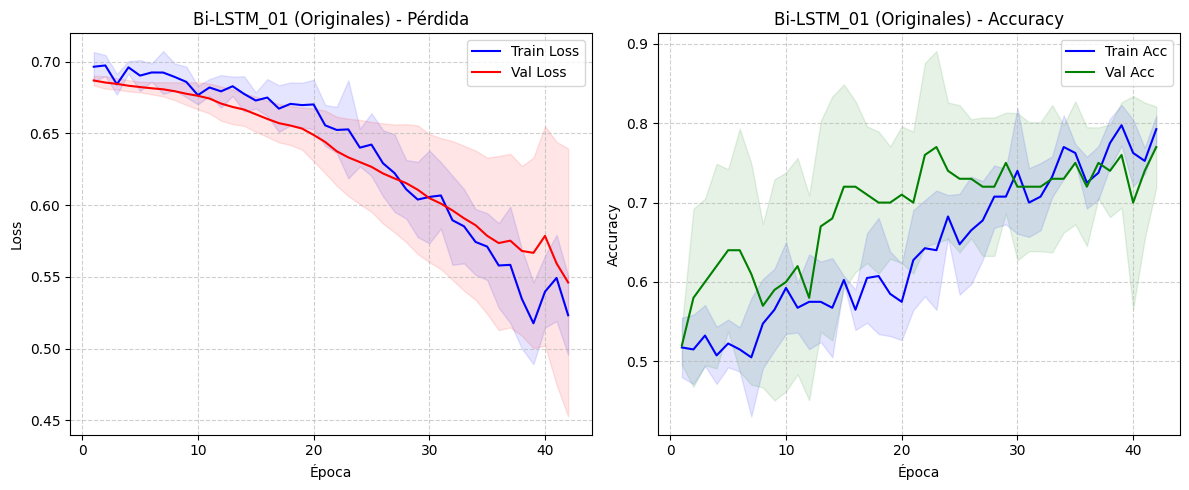

Calculando Bootstrap
Accuracy Promedio (Bootstrap): 0.7700
Intervalo de Confianza 95%: [0.6900, 0.8500]
Guardado como 'Bi-LSTM_01_SOLO_ORIGINAL'. Acc: 0.7700


In [24]:
_, _ = ejecutar_experimento_sin_aumentación(
    name='Bi-LSTM_01', 
    lstm_layers=[128, 64],
    dense_layers=[64, 32],
    dropout=0.3,
    lr=0.00005,
    opt_name='adam',
    bidirectional=True,
    patience=20,
    epochs=120
)

## Experimentación sin aumentación con Ángulos

In [25]:
import numpy as np

# Cargar los datos
X_correct_original = np.load('../Data/Processed/correct_push_ups_angles.npy')
X_incorrect_original = np.load('../Data/Processed/wrong_push_ups_angles.npy')

X_test_original = np.vstack((X_correct_original, X_incorrect_original))
y_test_original = np.array([1]*len(X_correct_original) + [0]*len(X_incorrect_original))

# Grupos simples 
groups_original = np.arange(len(X_test_original))

print("Datos para prueba sin espejos preparados:")
print(f"X: {X_test_original.shape}")
print(f"y: {y_test_original.shape}")

Datos para prueba sin espejos preparados:
X: (100, 160, 10)
y: (100,)


### Exp-LSTM-02

Test de solo originales (sin data augmentation)
Iniciando: LSTM_02
------------------------------------------------------------
GroupKFold Keras (5 splits)
(Grupos detectados: 100)

Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fin Fold 1. Acc Val: 0.9500 | Loss: 0.4711

Pliegue 2/5
Fin Fold 2. Acc Val: 0.9000 | Loss: 0.5256

Pliegue 3/5
Fin Fold 3. Acc Val: 0.8500 | Loss: 0.5951

Pliegue 4/5
Fin Fold 4. Acc Val: 0.9000 | Loss: 0.5027

Pliegue 5/5
Fin Fold 5. Acc Val: 0.8000 | Loss: 0.6289
Resultados GroupKFold:
Accuracy Medio: 0.8800
Desviación Std: 0.0510

Curvas de aprendizaje (Solo Originales)
Graficando las primeras 100 épocas comunes


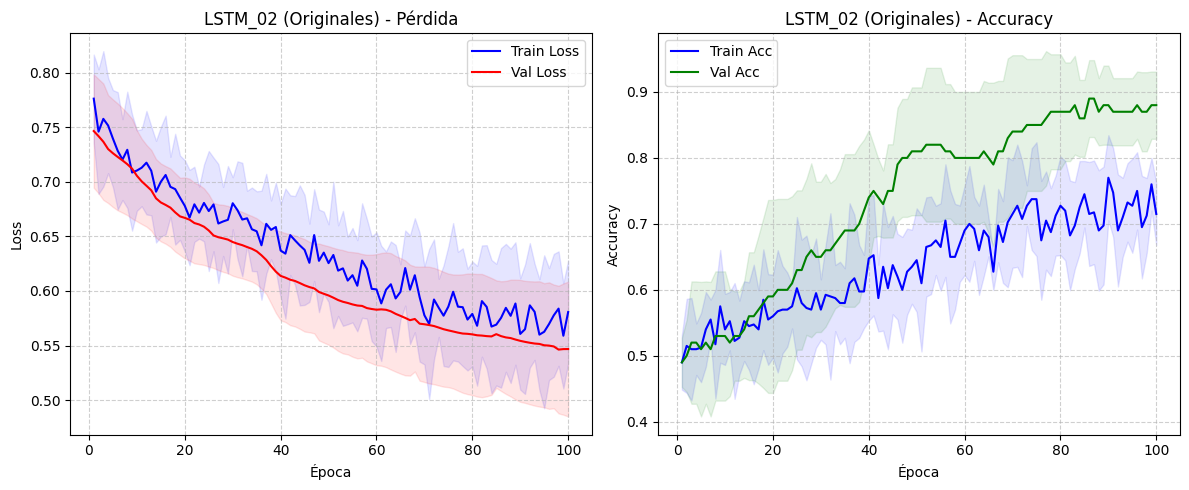

Calculando Bootstrap
Accuracy Promedio (Bootstrap): 0.8800
Intervalo de Confianza 95%: [0.8200, 0.9400]
Guardado como 'LSTM_02_SOLO_ORIGINAL'. Acc: 0.8800


In [26]:
_, _ = ejecutar_experimento_sin_aumentación( 
    name='LSTM_02', 
    lstm_layers=[64],
    dense_layers=[32],
    dropout=0.2,
    lr=0.00005,            
    opt_name='adam',
    patience=15,           
    epochs=100             
)

### Exp-Bi-LSTM-02

Test de solo originales (sin data augmentation)
Iniciando: Bi-LSTM_02
------------------------------------------------------------
GroupKFold Keras (5 splits)
(Grupos detectados: 100)

Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fin Fold 1. Acc Val: 0.9000 | Loss: 0.2820

Pliegue 2/5
Fin Fold 2. Acc Val: 0.8500 | Loss: 0.3052

Pliegue 3/5
Fin Fold 3. Acc Val: 1.0000 | Loss: 0.1667

Pliegue 4/5
Fin Fold 4. Acc Val: 0.8500 | Loss: 0.3077

Pliegue 5/5
Fin Fold 5. Acc Val: 0.9000 | Loss: 0.2564
Resultados GroupKFold:
Accuracy Medio: 0.9000
Desviación Std: 0.0548

Curvas de aprendizaje (Solo Originales)
Graficando las primeras 100 épocas comunes


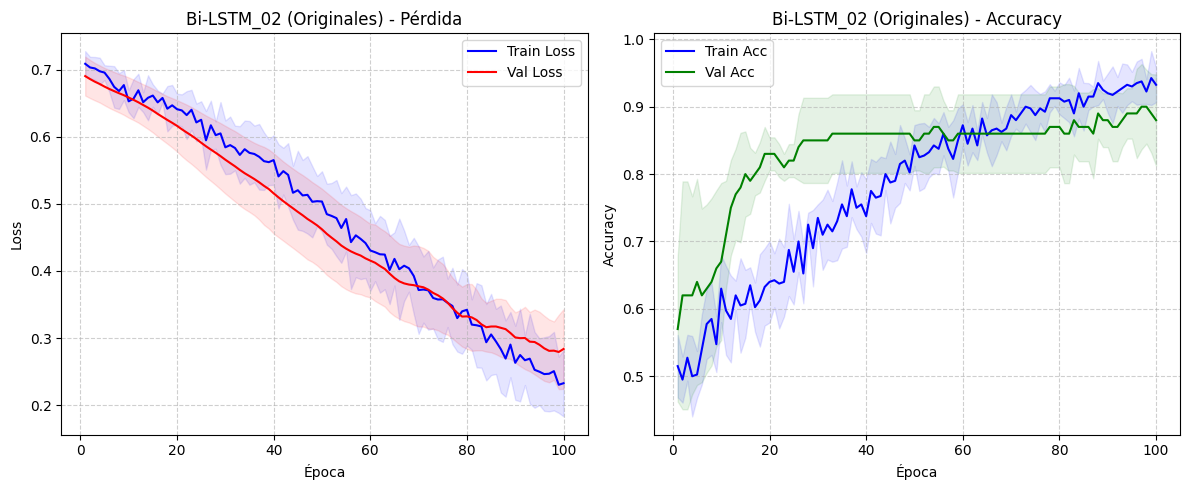

Calculando Bootstrap
Accuracy Promedio (Bootstrap): 0.9000
Intervalo de Confianza 95%: [0.8400, 0.9500]
Guardado como 'Bi-LSTM_02_SOLO_ORIGINAL'. Acc: 0.9000


In [27]:
_, _ = ejecutar_experimento_sin_aumentación(
    name='Bi-LSTM_02', 
    lstm_layers=[128, 64],
    dense_layers=[64, 32],
    dropout=0.3,
    lr=0.00005,
    opt_name='adam',
    bidirectional=True,
    patience=20,
    batch_size=32,
    epochs=100
)

In [28]:
import pandas as pd

# Convertimos la lista en un DataFrame
df_resultados = pd.DataFrame(results_table)

# Mostramos la tabla
print(f"Total de experimentos registrados: {len(df_resultados)}")
display(df_resultados) 

Total de experimentos registrados: 11


,Modelo,Acc CV,Acc Boot,IC 95%,LSTM Layers,Bidirectional,Dense Layers,Optimizador,Batch_size,Epochs,LR,Dropout,Patience,Dataset
0,LSTM_entrenamiento,0.865,0.865061,[0.815-0.910],[128],False,[32],adam,16,40,0.00010,0.20,10,NaN
1,LSTM_03,0.890,0.890104,[0.845-0.930],"[128, 64]",False,"[64, 32]",adam,16,100,0.00005,0.20,15,NaN
2,Bi-LSTM_03,0.875,0.874563,[0.825-0.920],"[128, 64]",True,"[64, 32]",adam,16,80,0.00005,0.25,10,NaN
3,LSTM_04,0.980,0.980001,[0.960-0.995],"[256, 128]",False,"[64, 32]",adam,16,80,0.00005,0.30,15,NaN
4,LSTM_Angles_Try2,0.970,0.969927,[0.945-0.990],"[128, 64]",False,"[64, 32]",adam,16,100,0.00005,0.20,15,NaN
5,Bi-LSTM_04,0.970,0.970133,[0.945-0.990],"[128, 64]",True,"[64, 32]",adam,16,120,0.00005,0.30,20,NaN
6,LSTM_01_SOLO_ORIGINAL,0.810,0.809529,[0.730-0.880],[64],False,[32],adam,16,40,0.00100,0.20,15,SOLO_ORIGINAL
7,LSTM_01-deep_SOLO_ORIGINAL,0.780,0.780781,[0.700-0.860],"[128, 64]",False,"[64, 32]",adam,16,100,0.00100,0.20,15,SOLO_ORIGINAL
8,Bi-LSTM_01_SOLO_ORIGINAL,0.770,0.769979,[0.690-0.850],"[128, 64]",True,"[64, 32]",adam,16,120,0.00005,0.30,20,SOLO_ORIGINAL
9,LSTM_02_SOLO_ORIGINAL,0.880,0.879966,[0.820-0.940],[64],False,[32],adam,16,100,0.00005,0.20,15,SOLO_ORIGINAL


In [29]:
# Borramos algunos experimentos que finalmente no se consideraron relevantes
df_final = df_resultados.drop([0, 4])

# Mostramos la tabla
print(f"Total de experimentos registrados: {len(df_final)}")
display(df_final) 

Total de experimentos registrados: 9


,Modelo,Acc CV,Acc Boot,IC 95%,LSTM Layers,Bidirectional,Dense Layers,Optimizador,Batch_size,Epochs,LR,Dropout,Patience,Dataset
1,LSTM_03,0.890,0.890104,[0.845-0.930],"[128, 64]",False,"[64, 32]",adam,16,100,0.00005,0.20,15,NaN
2,Bi-LSTM_03,0.875,0.874563,[0.825-0.920],"[128, 64]",True,"[64, 32]",adam,16,80,0.00005,0.25,10,NaN
3,LSTM_04,0.980,0.980001,[0.960-0.995],"[256, 128]",False,"[64, 32]",adam,16,80,0.00005,0.30,15,NaN
5,Bi-LSTM_04,0.970,0.970133,[0.945-0.990],"[128, 64]",True,"[64, 32]",adam,16,120,0.00005,0.30,20,NaN
6,LSTM_01_SOLO_ORIGINAL,0.810,0.809529,[0.730-0.880],[64],False,[32],adam,16,40,0.00100,0.20,15,SOLO_ORIGINAL
7,LSTM_01-deep_SOLO_ORIGINAL,0.780,0.780781,[0.700-0.860],"[128, 64]",False,"[64, 32]",adam,16,100,0.00100,0.20,15,SOLO_ORIGINAL
8,Bi-LSTM_01_SOLO_ORIGINAL,0.770,0.769979,[0.690-0.850],"[128, 64]",True,"[64, 32]",adam,16,120,0.00005,0.30,20,SOLO_ORIGINAL
9,LSTM_02_SOLO_ORIGINAL,0.880,0.879966,[0.820-0.940],[64],False,[32],adam,16,100,0.00005,0.20,15,SOLO_ORIGINAL
10,Bi-LSTM_02_SOLO_ORIGINAL,0.900,0.900008,[0.840-0.950],"[128, 64]",True,"[64, 32]",adam,32,100,0.00005,0.30,20,SOLO_ORIGINAL
